# 11 - NBBO and Spread Sanity (Granular)

## Objetivo cientifico
Caracterizar la calidad de quotes locales con enfoque granular para entender sesgos y micro-anomalias:
- spread negativo/crossed,
- spread locked,
- colas de spread,
- concentracion por dia/sesion/hora/archivo.

## Alcance
Este control valida coherencia interna del dataset local de quotes. No reconstruye NBBO oficial consolidado completo.

## Politica
- Sin `bid/ask`: `NOT_APPLICABLE`.
- Con `bid/ask`: gate PASS/WARN/FAIL calibrado historicamente.




## Paso 1 - Setup y muestra controlada



In [1]:
NOTEBOOK_ID = "11_nbbo_spread_sanity"

import json
import os
import sys
import uuid
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import polars as pl

try:
    import matplotlib.pyplot as plt
except Exception as e:
    plt = None
    print("matplotlib not available:", e)


def detect_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd] + list(cwd.parents)
    for cand in candidates:
        if (cand / "data" / "manifests").exists() and (cand / "notebooks" / "01_data_integrity").exists():
            return cand
    return cwd

PROJECT_ROOT = detect_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

DATA_ROOT = Path(os.getenv("DATA_CACHE_DIR", r"C:\TSIS_Data\data")).resolve()
SYMBOLS = ["AABA"]
MAX_FILES = 300
ROWS_PER_FILE = 2000

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S") + "_" + uuid.uuid4().hex[:8]
OUT_DIR = PROJECT_ROOT / "runs" / "data_quality" / NOTEBOOK_ID / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

try:
    git_commit = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=PROJECT_ROOT).decode().strip()
except Exception:
    git_commit = "<unknown>"

print("Run ID:", RUN_ID)
print("Out dir:", OUT_DIR)
print("Data root:", DATA_ROOT)
print("Symbols:", SYMBOLS)


def list_quote_files(data_root: Path, symbols: list[str], max_files: int) -> list[Path]:
    files = []
    roots = ["quotes_p95", "quotes_p95_2004_2018", "quotes_p95_2019_2025"]
    for r in roots:
        for s in symbols:
            base = data_root / r / s
            if not base.exists():
                continue
            for fp in base.rglob("*.parquet"):
                files.append(fp)
                if len(files) >= max_files:
                    return files
    return files


def sample_concat(files: list[Path], rows_per_file: int) -> pl.DataFrame:
    parts = []
    for fp in files:
        try:
            df = pl.read_parquet(fp).head(rows_per_file)
            parts.append(df)
        except Exception:
            continue
    if not parts:
        return pl.DataFrame()
    return pl.concat(parts, how="diagonal_relaxed")



Run ID: 20260213_182538_4fe3b626
Out dir: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\11_nbbo_spread_sanity\20260213_182538_4fe3b626
Data root: C:\TSIS_Data\data
Symbols: ['AABA']


**Interpretacion de salida anterior**

Esta salida confirma trazabilidad del run (`RUN_ID`, `OUT_DIR`) y el alcance de muestra. Si estos valores no aparecen, el notebook no es auditable.



## Paso 2A - Schema gate



In [2]:
quote_files = list_quote_files(DATA_ROOT, SYMBOLS, MAX_FILES)
quotes = sample_concat(quote_files, ROWS_PER_FILE)

bid_col = next((c for c in ["bid", "bid_price", "bp"] if c in quotes.columns), None)
ask_col = next((c for c in ["ask", "ask_price", "ap"] if c in quotes.columns), None)
ts_col = next((c for c in ["timestamp", "participant_timestamp", "t", "ts"] if c in quotes.columns), None)

print("rows:", quotes.height)
print("columns:", sorted(quotes.columns))
print("bid_col:", bid_col, "ask_col:", ask_col, "ts_col:", ts_col)

schema_gate = pl.DataFrame([
    {
        "rows_sampled": int(quotes.height),
        "quote_files_sampled": int(len(quote_files)),
        "bid_col": bid_col,
        "ask_col": ask_col,
        "timestamp_col": ts_col,
        "spread_check_status": "available" if (bid_col is not None and ask_col is not None) else "not_available",
    }
])

schema_gate



rows: 600000
columns: ['ask_exchange', 'ask_price', 'ask_size', 'bid_exchange', 'bid_price', 'bid_size', 'conditions', 'indicators', 'participant_timestamp', 'sequence_number', 'tape', 'timestamp']
bid_col: bid_price ask_col: ask_price ts_col: timestamp


rows_sampled,quote_files_sampled,bid_col,ask_col,timestamp_col,spread_check_status
i64,i64,str,str,str,str
600000,300,"""bid_price""","""ask_price""","""timestamp""","""available"""


**Interpretacion de salida anterior**

- Si `spread_check_status=available`, el control es aplicable.
- Si `not_available`, el resultado final debe ser `NOT_APPLICABLE` (no PASS).

Resumen observado (se completa tras ejecutar):
- `rows_sampled`: `600000`
- `bid_col`: `bid_price`, `ask_col`: `ask_price`



## Paso 2B - Metricas globales



In [3]:
if quotes.height == 0 or bid_col is None or ask_col is None:
    q = pl.DataFrame()
    spread_metrics = pl.DataFrame([
        {
            "n_quotes": 0,
            "negative_spread_rate": None,
            "locked_spread_rate": None,
            "crossed_spread_rate": None,
            "spread_bps_p99": None,
            "spread_check_status": "not_available",
        }
    ])
else:
    q = (
        quotes.with_columns([
            pl.col(bid_col).cast(pl.Float64, strict=False).alias("bid_px"),
            pl.col(ask_col).cast(pl.Float64, strict=False).alias("ask_px"),
        ])
        .drop_nulls(["bid_px", "ask_px"])
        .filter(pl.col("bid_px") > 0)
        .filter(pl.col("ask_px") > 0)
        .with_columns([
            (pl.col("ask_px") - pl.col("bid_px")).alias("spread"),
            ((pl.col("ask_px") - pl.col("bid_px")) / ((pl.col("ask_px") + pl.col("bid_px")) / 2.0) * 1e4).alias("spread_bps"),
            (pl.col("ask_px") < pl.col("bid_px")).alias("is_crossed"),
            (pl.col("ask_px") == pl.col("bid_px")).alias("is_locked"),
            (pl.col("ask_px") <= pl.col("bid_px")).alias("is_locked_or_crossed"),
        ])
    )

    n = q.height
    n_crossed = q.filter(pl.col("is_crossed")).height
    n_locked = q.filter(pl.col("is_locked")).height
    n_neg = q.filter(pl.col("spread") < 0).height

    spread_metrics = pl.DataFrame([
        {
            "n_quotes": int(n),
            "negative_spread_rate": float(n_neg / n) if n else None,
            "locked_spread_rate": float(n_locked / n) if n else None,
            "crossed_spread_rate": float(n_crossed / n) if n else None,
            "spread_bps_p99": float(q.select(pl.col("spread_bps").quantile(0.99)).item()) if n else None,
            "spread_check_status": "available",
        }
    ])

spread_metrics



n_quotes,negative_spread_rate,locked_spread_rate,crossed_spread_rate,spread_bps_p99,spread_check_status
i64,f64,f64,f64,f64,str
600000,0.000043,0.048588,0.000043,18.022446,"""available"""


**Interpretacion de salida anterior**

Esta tabla resume la foto global.

Resumen observado (se completa tras ejecutar):
- `negative_spread_rate`: `0.00004333`
- `crossed_spread_rate`: `0.00004333`
- `locked_spread_rate`: `0.048588`
- `spread_bps_p99`: `18.022446`

Clave: crossed/negative bajos no implican cero sesgo; por eso se analiza granularidad.



## Paso 2C - Granularidad por archivo/dia/sesion



In [4]:
def _path_meta(fp: Path) -> dict:
    rel = fp.relative_to(DATA_ROOT)
    parts = rel.parts
    dataset_root = parts[0] if len(parts) > 0 else "<unknown>"
    ticker = parts[1] if len(parts) > 1 else "<unknown>"
    day = None
    for part in parts:
        if part.startswith("day="):
            day = part.split("=", 1)[1]
            break
    return {
        "dataset_root": dataset_root,
        "ticker": ticker,
        "day": day,
        "session": fp.stem,
        "file_path": str(fp),
    }


def _file_spread_metrics(fp: Path, bid_name: str, ask_name: str, rows_per_file: int):
    try:
        cols = pl.read_parquet(fp, n_rows=1).columns
        if bid_name not in cols or ask_name not in cols:
            return None
        d = pl.read_parquet(fp, columns=[bid_name, ask_name]).head(rows_per_file)
        if d.height == 0:
            return None

        d = (
            d.with_columns([
                pl.col(bid_name).cast(pl.Float64, strict=False).alias("bid_px"),
                pl.col(ask_name).cast(pl.Float64, strict=False).alias("ask_px"),
            ])
            .drop_nulls(["bid_px", "ask_px"])
            .filter(pl.col("bid_px") > 0)
            .filter(pl.col("ask_px") > 0)
            .with_columns([
                (pl.col("ask_px") - pl.col("bid_px")).alias("spread"),
                ((pl.col("ask_px") - pl.col("bid_px")) / ((pl.col("ask_px") + pl.col("bid_px")) / 2.0) * 1e4).alias("spread_bps"),
            ])
        )

        n = d.height
        if n == 0:
            return {
                "n_quotes": 0,
                "negative_spread_rate": 0.0,
                "locked_spread_rate": 0.0,
                "crossed_spread_rate": 0.0,
                "spread_bps_p99": 0.0,
            }

        n_cross = d.filter(pl.col("spread") < 0).height
        n_lock = d.filter(pl.col("spread") == 0).height
        return {
            "n_quotes": int(n),
            "negative_spread_rate": float(n_cross / n),
            "locked_spread_rate": float(n_lock / n),
            "crossed_spread_rate": float(n_cross / n),
            "spread_bps_p99": float(d.select(pl.col("spread_bps").quantile(0.99)).item()),
        }
    except Exception:
        return None


file_rows = []
if bid_col is not None and ask_col is not None:
    for fp in quote_files:
        m = _file_spread_metrics(fp, bid_col, ask_col, ROWS_PER_FILE)
        if m is None:
            continue
        file_rows.append({**_path_meta(fp), **m})

gran_file = pl.DataFrame(file_rows) if file_rows else pl.DataFrame()

if gran_file.height > 0:
    gran_day_session = gran_file.select([
        "dataset_root", "ticker", "day", "session", "n_quotes",
        "negative_spread_rate", "locked_spread_rate", "crossed_spread_rate", "spread_bps_p99"
    ]).sort(["day", "session"])

    session_rollup = (
        gran_day_session.group_by("session").agg([
            pl.col("n_quotes").sum().alias("n_quotes"),
            (pl.col("crossed_spread_rate") * pl.col("n_quotes")).sum().alias("crossed_weighted_sum"),
            (pl.col("locked_spread_rate") * pl.col("n_quotes")).sum().alias("locked_weighted_sum"),
        ]).with_columns([
            pl.when(pl.col("n_quotes") > 0).then(pl.col("crossed_weighted_sum") / pl.col("n_quotes")).otherwise(0.0).alias("crossed_spread_rate_w"),
            pl.when(pl.col("n_quotes") > 0).then(pl.col("locked_weighted_sum") / pl.col("n_quotes")).otherwise(0.0).alias("locked_spread_rate_w"),
        ])
    )
else:
    gran_day_session = pl.DataFrame()
    session_rollup = pl.DataFrame()

print("Top archivos por crossed_spread_rate:")
if gran_file.height > 0:
    print(gran_file.select(["day", "session", "n_quotes", "crossed_spread_rate", "locked_spread_rate", "spread_bps_p99"]).sort("crossed_spread_rate", descending=True).head(10))
else:
    print("No granular rows computed")

session_rollup



Top archivos por crossed_spread_rate:
shape: (10, 6)
┌─────┬─────────┬──────────┬─────────────────────┬────────────────────┬────────────────┐
│ day ┆ session ┆ n_quotes ┆ crossed_spread_rate ┆ locked_spread_rate ┆ spread_bps_p99 │
│ --- ┆ ---     ┆ ---      ┆ ---                 ┆ ---                ┆ ---            │
│ str ┆ str     ┆ i64      ┆ f64                 ┆ f64                ┆ f64            │
╞═════╪═════════╪══════════╪═════════════════════╪════════════════════╪════════════════╡
│ 06  ┆ quotes  ┆ 2000     ┆ 0.0025              ┆ 0.052              ┆ 2.639219       │
│ 06  ┆ quotes  ┆ 2000     ┆ 0.0025              ┆ 0.052              ┆ 2.639219       │
│ 16  ┆ quotes  ┆ 2000     ┆ 0.0015              ┆ 0.0005             ┆ 31.550718      │
│ 24  ┆ quotes  ┆ 2000     ┆ 0.001               ┆ 0.07               ┆ 5.113782       │
│ 07  ┆ quotes  ┆ 2000     ┆ 0.001               ┆ 0.016              ┆ 2.866972       │
│ 16  ┆ quotes  ┆ 2000     ┆ 0.001               ┆ 0.0625

session,n_quotes,crossed_weighted_sum,locked_weighted_sum,crossed_spread_rate_w,locked_spread_rate_w
str,i64,f64,f64,f64,f64
"""quotes""",600000,26.0,29153.0,0.000043,0.048588


**Interpretacion de salida anterior**

Aqu? buscamos sesgos localizados.

Resumen observado (se completa tras ejecutar):
- sesion con mayor `crossed_spread_rate_w`: `quotes`
- valor: `0.00004333`
- archivo extremo (`day/session`) con mayor crossed: `06/quotes (0.002500)`

Si hay concentraci?n por sesi?n, el problema no es global: es segmentado.



## Paso 3A - Visuales de sesgo



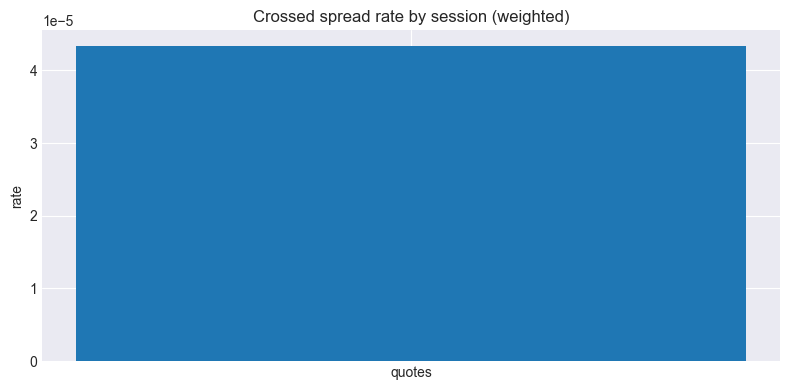

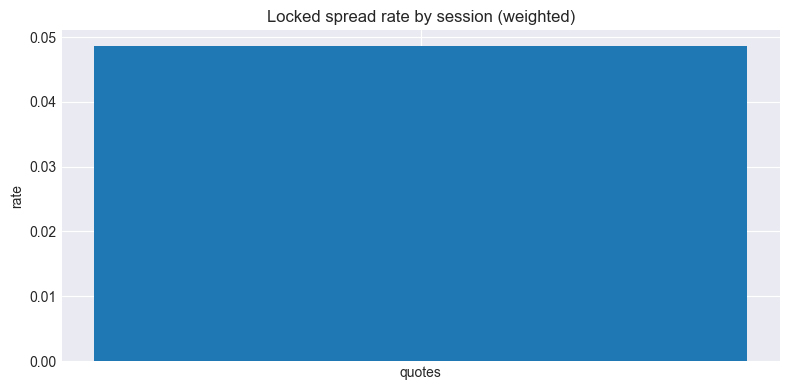

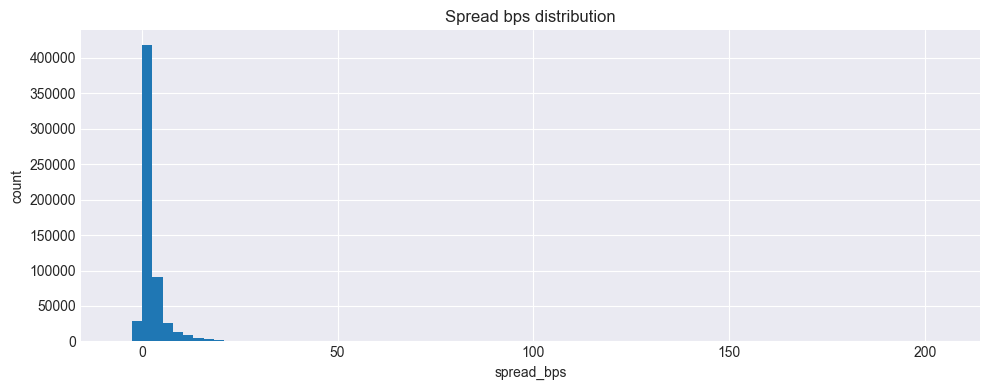

In [5]:
if plt is not None and session_rollup.height > 0:
    sp = pd.DataFrame(session_rollup.to_dicts())
    plt.style.use("seaborn-v0_8-darkgrid")

    plt.figure(figsize=(8, 4))
    plt.bar(sp["session"].astype(str), sp["crossed_spread_rate_w"])
    plt.title("Crossed spread rate by session (weighted)")
    plt.ylabel("rate")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.bar(sp["session"].astype(str), sp["locked_spread_rate_w"])
    plt.title("Locked spread rate by session (weighted)")
    plt.ylabel("rate")
    plt.tight_layout()
    plt.show()

if plt is not None and q.height > 0:
    qp = pd.DataFrame(q.select(["spread_bps"]).to_dicts())
    if not qp.empty:
        plt.figure(figsize=(10, 4))
        plt.hist(qp["spread_bps"], bins=80)
        plt.title("Spread bps distribution")
        plt.xlabel("spread_bps")
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()



**Interpretacion de salida anterior**

Los gr?ficos hacen visibles sesgos que la media global puede ocultar.
- Si una sesi?n domina anomal?as, priorizar revisi?n de esa sesi?n.
- Si la cola de spread se ensancha, revisar d?as/reg?menes extremos.



## Paso 3B - Muestras de micro-anomalias



In [6]:
if q.height > 0:
    sample_crossed = q.filter(pl.col("is_crossed")).select(["bid_px", "ask_px", "spread", "spread_bps"]).head(20)
    sample_locked = q.filter(pl.col("is_locked")).select(["bid_px", "ask_px", "spread", "spread_bps"]).head(20)
else:
    sample_crossed = pl.DataFrame()
    sample_locked = pl.DataFrame()

print("sample_crossed_rows:", sample_crossed.height)
print(sample_crossed)
print("\nsample_locked_rows:", sample_locked.height)
print(sample_locked)



sample_crossed_rows: 20
shape: (20, 4)
┌────────┬────────┬────────┬────────────┐
│ bid_px ┆ ask_px ┆ spread ┆ spread_bps │
│ ---    ┆ ---    ┆ ---    ┆ ---        │
│ f64    ┆ f64    ┆ f64    ┆ f64        │
╞════════╪════════╪════════╪════════════╡
│ 19.57  ┆ 19.56  ┆ -0.01  ┆ -5.111168  │
│ 19.57  ┆ 19.56  ┆ -0.01  ┆ -5.111168  │
│ 69.93  ┆ 69.92  ┆ -0.01  ┆ -1.430104  │
│ 69.93  ┆ 69.92  ┆ -0.01  ┆ -1.430104  │
│ 75.95  ┆ 75.94  ┆ -0.01  ┆ -1.316742  │
│ …      ┆ …      ┆ …      ┆ …          │
│ 19.57  ┆ 19.56  ┆ -0.01  ┆ -5.111168  │
│ 19.57  ┆ 19.56  ┆ -0.01  ┆ -5.111168  │
│ 69.93  ┆ 69.92  ┆ -0.01  ┆ -1.430104  │
│ 69.93  ┆ 69.92  ┆ -0.01  ┆ -1.430104  │
│ 75.95  ┆ 75.94  ┆ -0.01  ┆ -1.316742  │
└────────┴────────┴────────┴────────────┘

sample_locked_rows: 20
shape: (20, 4)
┌────────┬────────┬────────┬────────────┐
│ bid_px ┆ ask_px ┆ spread ┆ spread_bps │
│ ---    ┆ ---    ┆ ---    ┆ ---        │
│ f64    ┆ f64    ┆ f64    ┆ f64        │
╞════════╪════════╪════════╪════════════

**Interpretacion de salida anterior**

Estas muestras permiten validar si las micro-anomal?as parecen ruido puntual o patr?n sistem?tico.
Resumen observado (se completa tras ejecutar):
- `sample_crossed_rows`: `20`
- `sample_locked_rows`: `20`



## Paso 4 - Calibracion automatica y gate PASS/WARN/FAIL



In [7]:
runs_root = PROJECT_ROOT / "runs" / "data_quality" / NOTEBOOK_ID


def _quantile(vals: list[float], q: float) -> float:
    if not vals:
        return float("nan")
    x = sorted(float(v) for v in vals)
    if len(x) == 1:
        return x[0]
    pos = (len(x) - 1) * q
    lo = int(pos)
    hi = min(lo + 1, len(x) - 1)
    frac = pos - lo
    return x[lo] * (1.0 - frac) + x[hi] * frac


def _calibrate(vals: list[float], default_pass: float, default_warn: float) -> dict:
    vals = [float(v) for v in vals if v is not None]
    n = len(vals)
    if n >= 20:
        p_pass = _quantile(vals, 0.95)
        p_warn = _quantile(vals, 0.99)
        mode = "hist_p95_p99"
    elif n >= 5:
        p_pass = _quantile(vals, 0.90)
        p_warn = _quantile(vals, 0.98)
        mode = "hist_p90_p98"
    elif n > 0:
        p_pass = max(vals)
        p_warn = max(vals) * 1.25
        mode = "hist_max_buffer"
    else:
        p_pass = default_pass
        p_warn = default_warn
        mode = "default_fallback"

    p_pass = max(0.0, float(p_pass))
    p_warn = max(p_pass + 1e-12, float(p_warn))
    return {"n_history": n, "mode": mode, "pass_max": p_pass, "warn_max": p_warn}


def _status(value, pass_max: float, warn_max: float):
    if value is None:
        return "WARN", "metric_not_available"
    v = float(value)
    if v <= pass_max:
        return "PASS", "within_pass_threshold"
    if v <= warn_max:
        return "WARN", "within_warn_threshold"
    return "FAIL", "exceeds_warn_threshold"


metrics = schema_gate.hstack(spread_metrics.select([
    "n_quotes",
    "negative_spread_rate",
    "locked_spread_rate",
    "crossed_spread_rate",
    "spread_bps_p99",
]))

mrow = metrics.to_dicts()[0] if metrics.height > 0 else {}
has_spread = mrow.get("spread_check_status") == "available"
applicability_status = "APPLICABLE" if has_spread else "NOT_APPLICABLE"

hist_neg = []
hist_cross = []
hist_tail = []
if runs_root.exists():
    for d in sorted([x for x in runs_root.iterdir() if x.is_dir()], key=lambda x: x.stat().st_mtime):
        if d.name == RUN_ID:
            continue
        m_path = d / "nbbo_spread_metrics.parquet"
        if m_path.exists():
            try:
                hm = pl.read_parquet(m_path)
                if hm.height > 0:
                    row = hm.to_dicts()[0]
                    if row.get("negative_spread_rate") is not None:
                        hist_neg.append(float(row.get("negative_spread_rate")))
                    if row.get("crossed_spread_rate") is not None:
                        hist_cross.append(float(row.get("crossed_spread_rate")))
                    if row.get("spread_bps_p99") is not None:
                        hist_tail.append(float(row.get("spread_bps_p99")))
            except Exception:
                pass

thr_neg = _calibrate(hist_neg, default_pass=1e-5, default_warn=1e-4)
thr_cross = _calibrate(hist_cross, default_pass=1e-5, default_warn=1e-4)
thr_tail = _calibrate(hist_tail, default_pass=30.0, default_warn=100.0)

if applicability_status == "NOT_APPLICABLE":
    gate_breakdown = [
        {"gate": "spread_schema_coverage", "status": "NOT_APPLICABLE", "reason": "bid_or_ask_missing"},
        {"gate": "negative_spread_rate", "status": "NOT_APPLICABLE", "reason": "metric_not_available", "value": None, "pass_max": thr_neg["pass_max"], "warn_max": thr_neg["warn_max"], "history_n": thr_neg["n_history"], "mode": thr_neg["mode"]},
        {"gate": "crossed_spread_rate", "status": "NOT_APPLICABLE", "reason": "metric_not_available", "value": None, "pass_max": thr_cross["pass_max"], "warn_max": thr_cross["warn_max"], "history_n": thr_cross["n_history"], "mode": thr_cross["mode"]},
        {"gate": "spread_bps_p99", "status": "NOT_APPLICABLE", "reason": "metric_not_available", "value": None, "pass_max": thr_tail["pass_max"], "warn_max": thr_tail["warn_max"], "history_n": thr_tail["n_history"], "mode": thr_tail["mode"]},
    ]
    overall_status = "NOT_APPLICABLE"
else:
    s_neg, r_neg = _status(mrow.get("negative_spread_rate"), thr_neg["pass_max"], thr_neg["warn_max"])
    s_cross, r_cross = _status(mrow.get("crossed_spread_rate"), thr_cross["pass_max"], thr_cross["warn_max"])
    s_tail, r_tail = _status(mrow.get("spread_bps_p99"), thr_tail["pass_max"], thr_tail["warn_max"])

    gate_breakdown = [
        {"gate": "spread_schema_coverage", "status": "PASS", "reason": "bid_ask_available"},
        {"gate": "negative_spread_rate", "status": s_neg, "reason": r_neg, "value": mrow.get("negative_spread_rate"), "pass_max": thr_neg["pass_max"], "warn_max": thr_neg["warn_max"], "history_n": thr_neg["n_history"], "mode": thr_neg["mode"]},
        {"gate": "crossed_spread_rate", "status": s_cross, "reason": r_cross, "value": mrow.get("crossed_spread_rate"), "pass_max": thr_cross["pass_max"], "warn_max": thr_cross["warn_max"], "history_n": thr_cross["n_history"], "mode": thr_cross["mode"]},
        {"gate": "spread_bps_p99", "status": s_tail, "reason": r_tail, "value": mrow.get("spread_bps_p99"), "pass_max": thr_tail["pass_max"], "warn_max": thr_tail["warn_max"], "history_n": thr_tail["n_history"], "mode": thr_tail["mode"]},
    ]

    st = [g["status"] for g in gate_breakdown]
    if "FAIL" in st:
        overall_status = "FAIL"
    elif "WARN" in st:
        overall_status = "WARN"
    else:
        overall_status = "PASS"

calibration = {
    "negative_spread_rate": thr_neg,
    "crossed_spread_rate": thr_cross,
    "spread_bps_p99": thr_tail,
}

recommended_actions = []
if applicability_status == "NOT_APPLICABLE":
    recommended_actions.append({
        "priority": "high",
        "action": "ensure_quote_bid_ask_coverage",
        "detail": "Reingestar quotes con bid/ask para habilitar NBBO/spread sanity QA.",
    })
elif overall_status in {"WARN", "FAIL"}:
    recommended_actions.append({
        "priority": "high" if overall_status == "FAIL" else "medium",
        "action": "review_quote_quality_segments",
        "detail": "Analizar dias/sesiones con crossed/negative spread elevados y validar origen por particion/venue.",
    })

print("Applicability:", applicability_status)
print("Gate breakdown:", gate_breakdown)
print("OVERALL_STATUS:", overall_status)
print("Recommended actions:", recommended_actions)



Applicability: APPLICABLE
Gate breakdown: [{'gate': 'spread_schema_coverage', 'status': 'PASS', 'reason': 'bid_ask_available'}, {'gate': 'negative_spread_rate', 'status': 'PASS', 'reason': 'within_pass_threshold', 'value': 4.3333333333333334e-05, 'pass_max': 4.3333333333333334e-05, 'warn_max': 5.4166666666666664e-05, 'history_n': 2, 'mode': 'hist_max_buffer'}, {'gate': 'crossed_spread_rate', 'status': 'PASS', 'reason': 'within_pass_threshold', 'value': 4.3333333333333334e-05, 'pass_max': 4.3333333333333334e-05, 'warn_max': 5.4166666666666664e-05, 'history_n': 2, 'mode': 'hist_max_buffer'}, {'gate': 'spread_bps_p99', 'status': 'PASS', 'reason': 'within_pass_threshold', 'value': 18.022446137463184, 'pass_max': 24.97245684906379, 'warn_max': 31.215571061329737, 'history_n': 2, 'mode': 'hist_max_buffer'}]
OVERALL_STATUS: PASS
Recommended actions: []


**Interpretacion de salida anterior**

Resumen de decisi?n (se completa tras ejecutar):
- `applicability_status`: `APPLICABLE`
- `overall_status`: `PASS`
- gate m?s restrictivo: `PASS`

Este bloque conecta m?tricas con decisi?n operativa.



## Paso 5 - Export y decision



In [8]:
if metrics.height > 0:
    metrics.write_parquet(OUT_DIR / "nbbo_spread_metrics.parquet")
if gran_file.height > 0:
    gran_file.write_parquet(OUT_DIR / "nbbo_spread_granularity_by_file.parquet")
if gran_day_session.height > 0:
    gran_day_session.write_parquet(OUT_DIR / "nbbo_spread_granularity_by_day_session.parquet")

with open(OUT_DIR / "nbbo_spread_calibration.json", "w", encoding="utf-8") as f:
    json.dump(calibration, f, indent=2)

statuses = [g.get("status", "PASS") for g in gate_breakdown]
if applicability_status == "NOT_APPLICABLE":
    root_cause = "schema_gap"
elif any(s in {"FAIL", "WARN"} for s in statuses):
    root_cause = "microstructure_friction"
else:
    root_cause = "none"

decision_table = [{
    "ticker": SYMBOLS[0] if SYMBOLS else "<unknown>",
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "decision": overall_status,
}]

decision = {
    "check_id": "nbbo_spread_sanity_v3",
    "as_of_utc": datetime.now(timezone.utc).isoformat(),
    "git_commit": git_commit,
    "symbols": SYMBOLS,
    "applicability_status": applicability_status,
    "overall_status": overall_status,
    "root_cause": root_cause,
    "metrics": metrics.to_dicts(),
    "gate_breakdown": gate_breakdown,
    "decision_table": decision_table,
    "calibration": calibration,
    "recommended_actions": recommended_actions,
    "scope_note": "Local quote sanity proxy; not full official NBBO reconstruction.",
}

with open(OUT_DIR / "nbbo_spread_decision.json", "w", encoding="utf-8") as f:
    json.dump(decision, f, indent=2)

print("Saved:", OUT_DIR / "nbbo_spread_metrics.parquet")
print("Saved:", OUT_DIR / "nbbo_spread_granularity_by_file.parquet")
print("Saved:", OUT_DIR / "nbbo_spread_granularity_by_day_session.parquet")
print("Saved:", OUT_DIR / "nbbo_spread_calibration.json")
print("Saved:", OUT_DIR / "nbbo_spread_decision.json")
print("APPLICABILITY_STATUS:", applicability_status)
print("OVERALL_STATUS:", overall_status)



Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\11_nbbo_spread_sanity\20260213_182538_4fe3b626\nbbo_spread_metrics.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\11_nbbo_spread_sanity\20260213_182538_4fe3b626\nbbo_spread_granularity_by_file.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\11_nbbo_spread_sanity\20260213_182538_4fe3b626\nbbo_spread_granularity_by_day_session.parquet
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\11_nbbo_spread_sanity\20260213_182538_4fe3b626\nbbo_spread_calibration.json
Saved: C:\TSIS_Data\v1\backtest_SmallCaps\runs\data_quality\11_nbbo_spread_sanity\20260213_182538_4fe3b626\nbbo_spread_decision.json
APPLICABILITY_STATUS: APPLICABLE
OVERALL_STATUS: PASS


**Interpretacion final**

El valor de este notebook es convertir anomal?as de spread en evidencia accionable por segmento temporal.
Si el estado es `WARN/FAIL`, la acci?n no es descartar todo el dataset autom?ticamente, sino aislar r?gimen/sesi?n/partici?n problem?tica.

